In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [32]:
# ===================== Data Loading and Preprocessing =====================

df = pd.read_parquet('/Users/taojun/Desktop/test.parquet')
df.index = pd.to_datetime(df.index)
print(df)

# Separate the price and volume data.
price_data = pd.DataFrame()
volume_data = pd.DataFrame()

for col in df.columns:
    if isinstance(col, tuple) and len(col) == 2:
        ticker = col[0]
        field = col[1]
        if field == 'close':
            price_data[ticker] = df[col]
        elif field == 'volume':
            volume_data[ticker] = df[col]

# Identify the common elements.
common_stocks = list(set(price_data.columns) & set(volume_data.columns))
price_data = price_data[common_stocks]
volume_data = volume_data[common_stocks]

ticker                        SPY                     QQQ                \
field                       close        volume     close        volume   
datetime                                                                  
2026-03-16 09:30:00-04:00  668.57  2.022435e+06  600.8800  1.963621e+06   
2026-03-16 09:35:00-04:00  669.01  1.325973e+06  600.6700  9.397781e+05   
2026-03-16 09:40:00-04:00  669.64  1.358403e+06  600.3600  7.650286e+05   
2026-03-16 09:45:00-04:00  669.99  1.726517e+06  601.3800  1.135926e+06   
2026-03-16 09:50:00-04:00  669.80  1.360770e+06  601.0200  4.982209e+05   
...                           ...           ...       ...           ...   
2026-03-27 15:35:00-04:00  634.79  1.213779e+06  562.9900  9.373938e+05   
2026-03-27 15:40:00-04:00  634.17  1.861483e+06  562.5950  1.243039e+06   
2026-03-27 15:45:00-04:00  633.85  2.898495e+06  562.3250  1.580368e+06   
2026-03-27 15:50:00-04:00  634.05  2.915317e+06  562.4801  2.085662e+06   
2026-03-27 15:55:00-04:00

In [33]:
# ===================== Strategy Design =====================

class Strategy:
    """
   Short-term Reversal + Intraday Momentum Multi-factor Strategy
    """
    
    def __init__(self):
        # --- Hyperparameters ---
        self.lookback_short = 14       # 70 min (14 x 5-min bars) for reversal
        self.lookback_medium = 18      # 90 min (18 x 5-min bars) for momentum
        self.top_k = 15                # Number of stocks to hold
        
        # Optimized factor weights (from grid search)
        self.w_reversal = 0.70
        self.w_momentum = 0.30
        
        # --- State Variables ---
        max_lookback = max(self.lookback_short, self.lookback_medium) + 1
        self.price_history = deque(maxlen=max_lookback)
        self.step_count = 0
    
    def step(self, current_market_data: pd.DataFrame) -> pd.Series:
        prices = current_market_data["close"]
        tickers = prices.index
        
        # Update historical prices.
        self.price_history.append(prices.values.copy())
        self.step_count += 1
        
        # Wait for sufficient historical data.
        min_history = max(self.lookback_short, self.lookback_medium) + 1
        if self.step_count < min_history:
            return pd.Series(0.0, index=tickers)
        
        price_arr = np.array(self.price_history)
        current_prices = price_arr[-1]
        
        # Factor 1: Short-term reversal (30 min)
        past_short = price_arr[-1 - self.lookback_short]
        ret_short = (current_prices - past_short) / (past_short + 1e-10)
        reversal_signal = -ret_short   # buy losers
        
        # Factor 2: Intraday momentum (2 hours)
        past_medium = price_arr[-1 - self.lookback_medium]
        momentum_signal = (current_prices - past_medium) / (past_medium + 1e-10)
        
        # Rank-based composite scoring
        rank_rev = self._rank(reversal_signal)
        rank_mom = self._rank(momentum_signal)
        composite = self.w_reversal * rank_rev + self.w_momentum * rank_mom

        # Top-K equal weight
        top_indices = np.argsort(composite)[-self.top_k:]
        weights_arr = np.zeros(len(tickers))
        weights_arr[top_indices] = 1.0 / self.top_k
        
        return pd.Series(weights_arr, index=tickers)
    
    @staticmethod
    def _rank(arr):
        clean = np.where(np.isfinite(arr), arr, -np.inf)
        temp = clean.argsort().argsort()
        return temp / (len(temp) - 1 + 1e-10)

In [34]:
# ===================== Strategy Backtesting Execution =====================

strategy = Strategy()

# Store daily holdings and profits.
portfolio_weights = []
selected_stocks_history = []

for timestamp in price_data.index:
    current_data = pd.DataFrame({
        "close": price_data.loc[timestamp]
    })
    
    weights = strategy.step(current_data)
    portfolio_weights.append(weights)
    
    selected_stocks = weights[weights > 0].index.tolist()
    selected_stocks_history.append(selected_stocks)

weights_df = pd.DataFrame(portfolio_weights, index=price_data.index)

# Calculate the return rate of a single stock.
returns = price_data.pct_change()

# Calculate the combined return (using the holdings on the current day and the return on the next day).
# Use the holding weights at time t to calculate the return at time t+1.
portfolio_returns = pd.Series(index=price_data.index, dtype=float)

for i in range(1, len(price_data.index)):
    current_time = price_data.index[i]
    prev_time = price_data.index[i-1]
    
    # Obtain the position weight of the previous moment.
    weights = weights_df.loc[prev_time]
    
    # Obtain the current yield rate.
    ret_today = returns.loc[current_time]
    
    # Calculate the combined return (only the held stocks are included in the calculation).
    selected = weights[weights > 0].index
    if len(selected) > 0:
        port_ret = (weights[selected] * ret_today[selected]).sum()
    else:
        port_ret = 0.0
    
    portfolio_returns[current_time] = port_ret

portfolio_returns = portfolio_returns.dropna()

# Cumulative Return Rate
cumulative_returns = (1 + portfolio_returns).cumprod() - 1

# Annualized Return Rate
total_bars = len(portfolio_returns)
years = total_bars / (252 * 78)
annualized_return = (1 + cumulative_returns.iloc[-1]) ** (1 / years) - 1

# Annualized Volatility
annualized_vol = portfolio_returns.std() * np.sqrt(252 * 78)

# Sharpe Ratio (assuming the risk-free interest rate is 0)
sharpe_ratio = annualized_return / annualized_vol if annualized_vol > 0 else 0

# Maximum Drawdown
cumulative = (1 + portfolio_returns).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max
max_drawdown = drawdown.min()

# Hit Ratio
win_rate = (portfolio_returns > 0).sum() / len(portfolio_returns)

Strategy Backtesting Results
Time Period             : 2026-03-16 09:30:00-04:00 to 2026-03-27 15:55:00-04:00
Number of Time Points   : 780
Number of Stocks Held.  : 15
Reversal Factor Weight  : 0.70
Momentum Factor Weight  : 0.30
------------------------------------------------------------
Cumulative Return       : 7.61%
Annualized Return.      : 536.48%
Annualized volatility.  : 23.96%
Sharpe Ratio            : 22.3875
Maximum Drawdown.       : -4.19%
Hit Ratio               : 51.60%


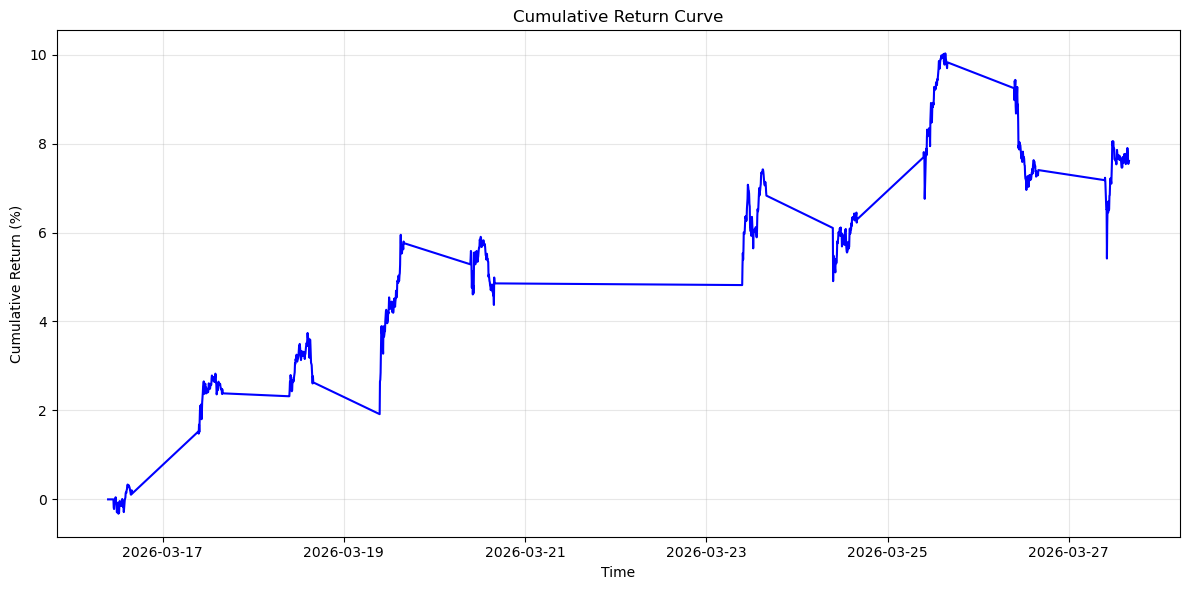

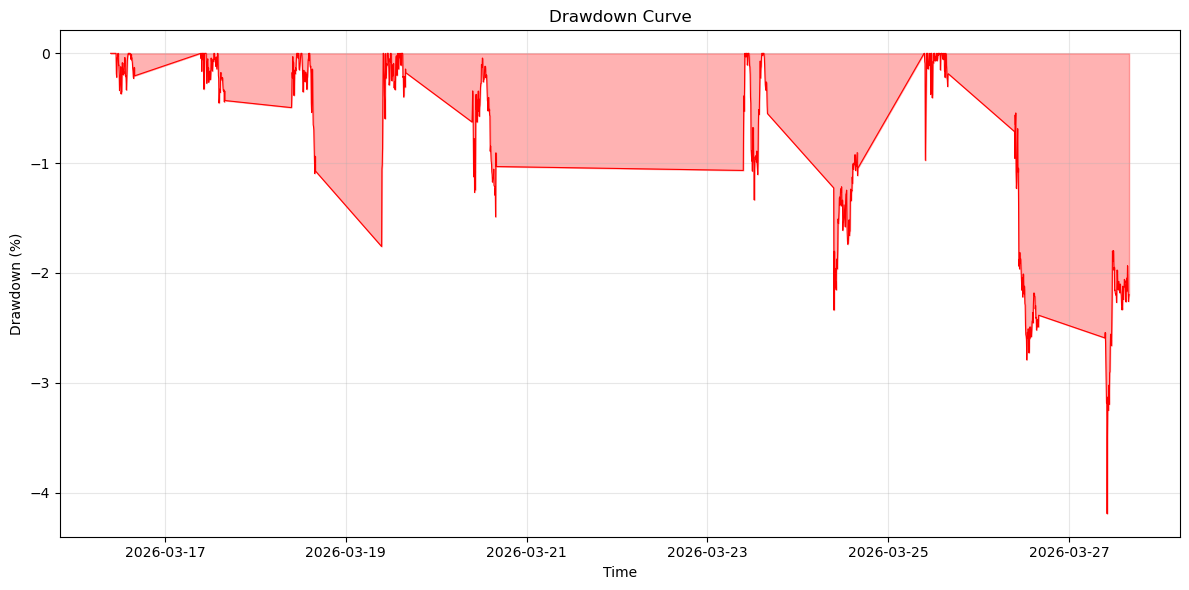

In [35]:
# ===================== Backtesting Result =====================

print("=" * 60)
print("Strategy Backtesting Results")
print("=" * 60)
print(f"Time Period             : {price_data.index[0]} to {price_data.index[-1]}")
print(f"Number of Time Points   : {len(price_data.index)}")
print(f"Number of Stocks Held.  : {strategy.top_k}")
print(f"Reversal Factor Weight  : {strategy.w_reversal:.2f}")
print(f"Momentum Factor Weight  : {strategy.w_momentum:.2f}")
print("-" * 60)
print(f"Cumulative Return       : {cumulative_returns.iloc[-1] * 100:.2f}%")
print(f"Annualized Return.      : {annualized_return * 100:.2f}%")
print(f"Annualized volatility.  : {annualized_vol * 100:.2f}%")
print(f"Sharpe Ratio            : {sharpe_ratio:.4f}")
print(f"Maximum Drawdown.       : {max_drawdown * 100:.2f}%")
print(f"Hit Ratio               : {win_rate * 100:.2f}%")
print("=" * 60)
# ===================== Visualized Results =====================

plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns.index, cumulative_returns * 100, 'b-', linewidth=1.5)
plt.title('Cumulative Return Curve')
plt.xlabel('Time')
plt.ylabel('Cumulative Return (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.fill_between(drawdown.index, drawdown * 100, 0, color='red', alpha=0.3)
plt.plot(drawdown.index, drawdown * 100, 'r-', linewidth=0.8)
plt.title('Drawdown Curve')
plt.xlabel('Time')
plt.ylabel('Drawdown (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()